<a href="https://colab.research.google.com/github/Elwing-Chou/tibame20260223/blob/main/20260311.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 象棋棋盤: https://i-blog.csdnimg.cn/blog_migrate/ee144a254459ba034fae2ff541b13d64.png
import pygame as pg

#pygame初始化
pg.init()

# --- 字型 ---
def get_font(size):
    for f in ['microsoftjhenghei', 'simhei', 'stheitirelight']:
        if f in pg.font.get_fonts():
            return pg.font.SysFont(f, size)
    return pg.font.SysFont(None, size)

# 32是字體的size
FONT_UI = get_font(32)

#設定視窗
width, height = 800, 880
inter = 80

# 回合數(0,2,4 黑)
game_round = 0
# 目前有無棋子選擇
chosen = (0, 0)

# 轉換字典: 整數->字串
# 陣營(0陣營: 黑 1陣營: 紅)
# key(腳色): (0陣營代表, 1陣營代表)
dic = {
    0:("將", "帥"),
    1:("士", "仕"),
    2:("象", "相"),
    3:("馬", "傌"),
    4:("車", "俥"),
    5:("包", "炮"),
    6:("卒", "兵"),
}

row, col = 10, 9
# 準備一個初始化的位置: -1: 沒東西 (腳色, 陣營)
board_role = [[-1] * col for i in range(row)]
# 將/帥
board_role[0][4] = (0, 0)
board_role[9][4] = (0, 1)
# 士
board_role[0][3] = (1, 0)
board_role[0][5] = (1, 0)
board_role[9][3] = (1, 1)
board_role[9][5] = (1, 1)
# 相
board_role[0][2] = (2, 0)
board_role[0][6] = (2, 0)
board_role[9][2] = (2, 1)
board_role[9][6] = (2, 1)
# 馬
board_role[0][1] = (3, 0)
board_role[0][7] = (3, 0)
board_role[9][1] = (3, 1)
board_role[9][7] = (3, 1)
# 俥
board_role[0][0] = (4, 0)
board_role[0][8] = (4, 0)
board_role[9][0] = (4, 1)
board_role[9][8] = (4, 1)
# 包
board_role[2][1] = (5, 0)
board_role[2][7] = (5, 0)
board_role[7][1] = (5, 1)
board_role[7][7] = (5, 1)
# 兵
for i in range(5):
    board_role[3][2*i] = (6, 0)
    board_role[6][2*i] = (6, 1)

# 準備一個紀錄所有座標的list
board_coords = [[-1] * col for i in range(row)]
for i in range(row):
    for j in range(col):
        board_coords[i][j] = (inter * j + inter, inter * i + inter)


# 產生視窗
screen = pg.display.set_mode([width, height])
# 設定遊戲標題
pg.display.set_caption("象棋")

def draw():
    # 建立畫布bg
    bg = pg.Surface(screen.get_size())
    # 把畫布填滿某個顏色
    bg.fill([199, 167, 82])

    # 畫上半部棋盤
    # line(圖層, 顏色, 開始座標, 結束座標, 粗度)
    for i in range(5):
        pg.draw.line(bg,
                     [0, 0, 0],
                     [inter, inter*i+inter],
                     [9*inter, inter*i+inter],
                     2)

    for i in range(9):
        pg.draw.line(bg,
                     [0, 0, 0],
                     [inter*i+inter, inter],
                     [inter*i+inter, 5*inter],
                     2)

    pg.draw.line(bg,
                 [0, 0, 0],
                 [4*inter, inter],
                 [6*inter, 3*inter],
                 2)

    pg.draw.line(bg,
                 [0, 0, 0],
                 [6*inter, inter],
                 [4*inter, 3*inter],
                 2)

    # lower half
    for i in range(5):
        pg.draw.line(bg,
                     [0, 0, 0],
                     [inter, inter*i+6*inter],
                     [9*inter, inter*i+6*inter],
                     2)

    for i in range(9):
        pg.draw.line(bg,
                     [0, 0, 0],
                     [inter*i+inter, 6*inter],
                     [inter*i+inter, 10*inter],
                     2)

    pg.draw.line(bg,
                 [0, 0, 0],
                 [4*inter, 8*inter],
                 [6*inter, 10*inter],
                 2)

    pg.draw.line(bg,
                 [0, 0, 0],
                 [6*inter, 8*inter],
                 [4*inter, 10*inter],
                 2)

    # 畫出其子
    for i in range(row):
        for j in range(col):
            # 有旗子
            if not board_role[i][j] == -1:
                role, side = board_role[i][j]
                if side == 0:
                    bg_color = (0, 0, 0)
                    font_color = (255, 255, 255)
                else:
                    bg_color = (255, 255, 255)
                    font_color = (255, 0, 0)
                # 塗層, 顏色, 圓心, 半徑, 粗度(!妳沒設的話是填滿)
                pg.draw.circle(bg,
                               bg_color,
                               board_coords[i][j],
                               30)
                # 準備填上去的字
                t = FONT_UI.render(dic[role][side], 1, font_color)
                # 背景(bg)上面疊上t
                bg.blit(t, t.get_rect(center=board_coords[i][j]))
    # 如果有選擇, 我就幫他加上一個綠色框框
    # 畫布, 顏色, [x坐標, y坐標, 寬度, 高度], 線寬
    if not chosen == None:
        i, j = chosen
        xc, yc = board_coords[i][j]
        pg.draw.rect(bg,
                     (0, 0, 255),
                     (xc-30, yc-30, 60, 60),
                     2)

    # 你要把圖層放到上一層
    screen.blit(bg, [0, 0])
    # 對畫面進行更新(才會真的秀出來)
    pg.display.update()

# 第一次繪製
draw()
# 建立一個永不結束的迴圈(遊戲才不會結束)
running = True
while running:
    # 收取你的遊戲任何事件(滑鼠點擊/鍵盤按鈕...)
    for event in pg.event.get():
        # 偵測滑鼠點擊以後放掉的動作
        if event.type == pg.MOUSEBUTTONUP:
            pass
        # 如果收到的事件是按x
        if event.type == pg.QUIT:
            # 迴圈就會變成while False
            running = False

pg.quit()

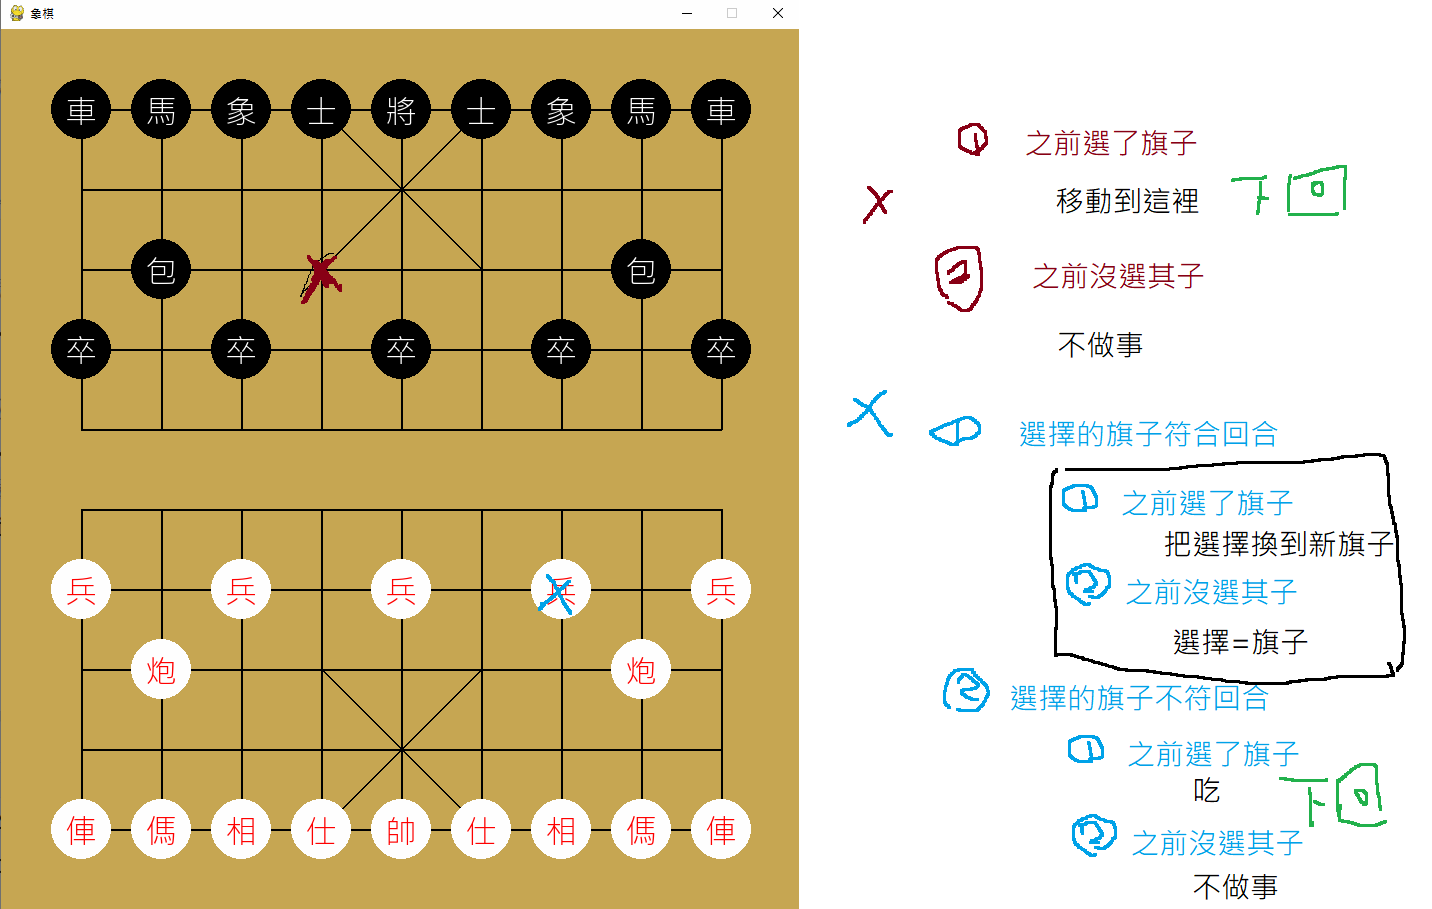

In [2]:
# 找最小值
# 我存一個數, 只要遇到比這個數還小的, 更新
minv = float("inf")
l = [30, 60, 20, 40]
for i in range(len(l)):
    n = l[i]
    if n < minv:
        minv = n
print(minv)

30
30
20
20
